# Exp4 现场测评：算法准确度与噪声强度关系评估

本测评旨在验证深度学习实例分割模型（Mask R-CNN）对环境噪声的抗干扰能力（鲁棒性）。
我们将对验证集图片逐级加入高斯噪声，并测试不同噪声强度下模型的 `Mask-AP` 精确度，最终绘制关系折线图。

In [1]:
import torch
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn_v2, MaskRCNN_ResNet50_FPN_V2_Weights
from torchvision.transforms import functional as F
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import pycocotools.mask as mask_util

# 设备自适应配置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备进行测评: {device}")

# 目录配置
BASE_DIR = os.path.abspath('.')
DATA_DIR = os.path.join(BASE_DIR, 'Segmentation', 'detectron2-main', 'datasets', 'coco')
VAL_IMG_DIR = os.path.join(DATA_DIR, 'val2017')
VAL_ANN_FILE = os.path.join(DATA_DIR, 'annotations', 'instances_val2017.json')
RESULTS_DIR = os.path.join(BASE_DIR, 'results_dl')
os.makedirs(RESULTS_DIR, exist_ok=True)

# 加载 COCO GT 数据
coco_gt = COCO(VAL_ANN_FILE)

# 加载预训练模型
weights = MaskRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model = maskrcnn_resnet50_fpn_v2(weights=weights).to(device)
model.eval()

使用设备进行测评: cuda
loading annotations into memory...


Done (t=0.50s)
creating index...
index created!


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         

## 1. 核心模块：噪声注入与单轮评估函数

In [2]:
def add_gaussian_noise(image_tensor, sigma):
    """
    向图像张量 [0, 1] 中加入指定强度的高斯噪声。
    sigma 的实际单位对应 0-255 的像素范围，为了适配 [0, 1] 的张量，我们会将其除以 255.0。
    """
    if sigma == 0:
        return image_tensor
    noise = torch.randn_like(image_tensor) * (sigma / 255.0)
    noisy_image = image_tensor + noise
    # 截断到合法像素范围
    return torch.clamp(noisy_image, 0.0, 1.0)

def evaluate_with_noise(model, img_dir, coco_gt_api, sigma, max_imgs=200):
    """
    带噪声干扰的评估测算。
    默认抽取 200 张图像进行极速验证，以快速获取曲线数据点。
    """
    model.eval()
    img_ids = coco_gt_api.getImgIds()[:max_imgs]
    results_list = []
    
    with torch.no_grad():
        for img_id in tqdm(img_ids, desc=f"Evaluating (Sigma={sigma})"):
            img_info = coco_gt_api.loadImgs(img_id)[0]
            img_path = os.path.join(img_dir, img_info['file_name'])
            
            # 加载并注入噪声
            img = Image.open(img_path).convert("RGB")
            img_tensor = F.to_tensor(img).to(device)
            noisy_tensor = add_gaussian_noise(img_tensor, sigma)
            
            # 推理
            prediction = model([noisy_tensor])[0]
            
            masks = prediction['masks'].cpu().numpy()
            boxes = prediction['boxes'].cpu().numpy()
            labels = prediction['labels'].cpu().numpy()
            scores = prediction['scores'].cpu().numpy()
            
            for i in range(len(scores)):
                # 丢弃极低置信度的结果以加速评测
                if scores[i] < 0.05:
                    continue
                mask_uint8 = np.asfortranarray((masks[i, 0] > 0.5).astype(np.uint8))
                rle = mask_util.encode(mask_uint8)
                rle['counts'] = rle['counts'].decode('utf-8')
                x1, y1, x2, y2 = boxes[i]
                results_list.append({
                    "image_id": img_id,
                    "category_id": int(labels[i]),
                    "bbox": [float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
                    "score": float(scores[i]),
                    "segmentation": rle
                })
                
    if not results_list:
        return 0.0

    # 使用 COCO API 计算 AP
    coco_dt = coco_gt_api.loadRes(results_list)
    coco_eval_mask = COCOeval(coco_gt_api, coco_dt, 'segm')
    coco_eval_mask.params.imgIds = img_ids
    # 关闭繁杂的控制台输出
    import contextlib, sys
    with contextlib.redirect_stdout(None):
        coco_eval_mask.evaluate()
        coco_eval_mask.accumulate()
        coco_eval_mask.summarize()
    
    mask_ap = coco_eval_mask.stats[0] # AP @ IoU=0.50:0.95
    return mask_ap

## 2. 自动化执行与结果记录
我们将测试不同的噪声强度梯队，并记录每次的成绩。

In [3]:
# 定义不同梯度的噪声强度参数 (标准差)
noise_intensities = [0, 10, 20, 30, 40, 50, 60]
ap_scores = []

print("🚀 开始进行现场测评验证：算法准确度与噪声强度测试")
print("-" * 50)

for sigma in noise_intensities:
    ap = evaluate_with_noise(model, VAL_IMG_DIR, coco_gt, sigma, max_imgs=200)
    ap_scores.append(ap)
    print(f"✅ 噪声强度 Sigma = {sigma:<2} | Mask-AP = {ap:.4f}")

🚀 开始进行现场测评验证：算法准确度与噪声强度测试
--------------------------------------------------


Evaluating (Sigma=0):   0%|          | 0/200 [00:00<?, ?it/s]

Evaluating (Sigma=0):   0%|          | 1/200 [00:00<02:13,  1.49it/s]

Evaluating (Sigma=0):   1%|          | 2/200 [00:00<01:14,  2.66it/s]

Evaluating (Sigma=0):   2%|▏         | 3/200 [00:00<00:50,  3.90it/s]

...

Evaluating (Sigma=60):  99%|█████████▉| 198/200 [00:20<00:00,  9.61it/s]

Evaluating (Sigma=60): 100%|█████████▉| 199/200 [00:21<00:00,  9.58it/s]

Evaluating (Sigma=60): 100%|██████████| 200/200 [00:21<00:00,  9.45it/s]

Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!


✅ 噪声强度 Sigma = 60 | Mask-AP = 0.1819


## 3. 绘制并保存精确度衰减曲线图


📊 测评关系图已生成并保存至: D:\Vscode\Project\DIP-Experiment\Exp4\results_dl\noise_accuracy_curve.png


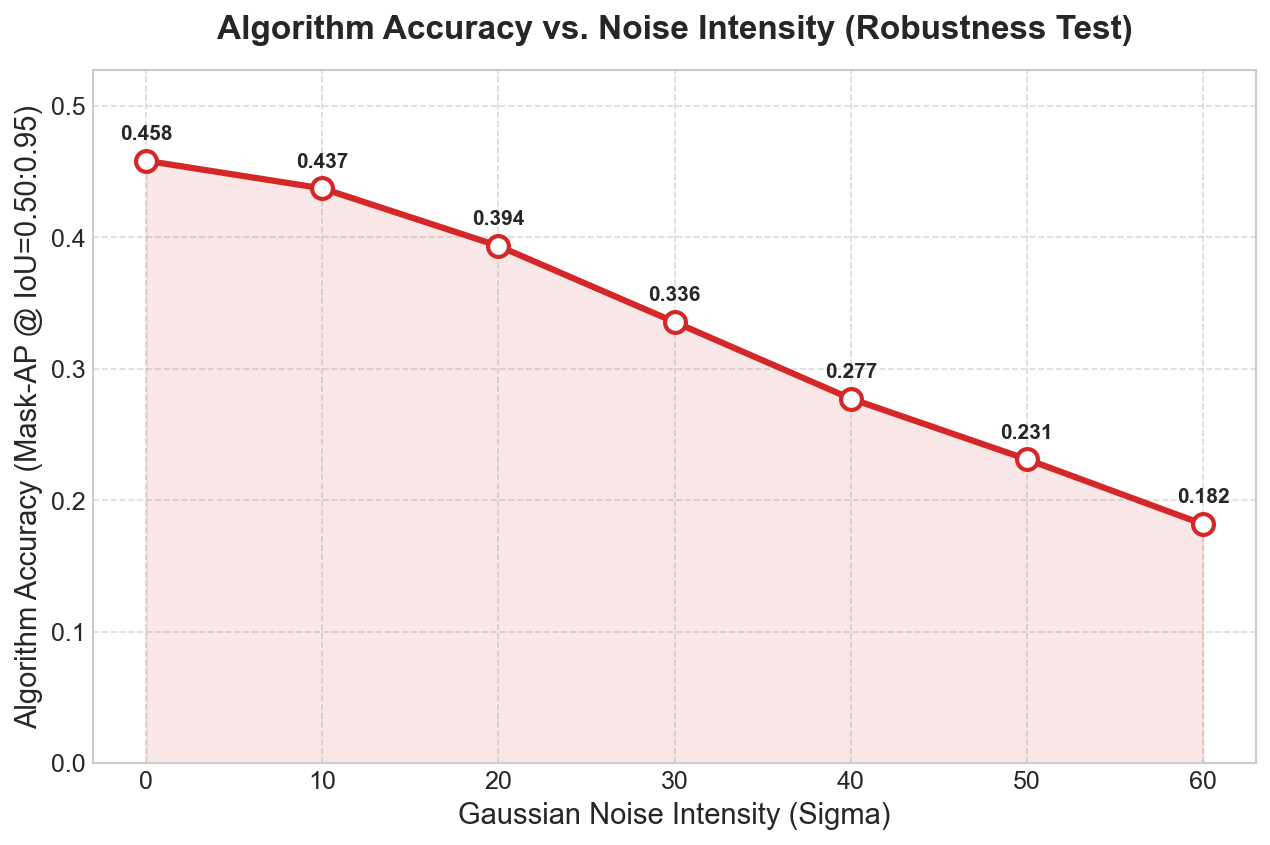

In [4]:
plt.figure(figsize=(10, 6), dpi=150)

# 设置唯美的绘图风格
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.plot(noise_intensities, ap_scores, marker='o', linewidth=3, markersize=10, color='#d62728', mfc='white', mew=2)

# 添加数值标签
for x, y in zip(noise_intensities, ap_scores):
    plt.annotate(f"{y:.3f}", (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, fontweight='bold')

plt.title('Algorithm Accuracy vs. Noise Intensity (Robustness Test)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Gaussian Noise Intensity (Sigma)', fontsize=14)
plt.ylabel('Algorithm Accuracy (Mask-AP @ IoU=0.50:0.95)', fontsize=14)
plt.xticks(noise_intensities, fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0, max(ap_scores) * 1.15)
plt.grid(True, linestyle='--', alpha=0.7)

# 标记下降趋势
plt.fill_between(noise_intensities, ap_scores, alpha=0.1, color='#d62728')

save_path = os.path.join(RESULTS_DIR, 'noise_accuracy_curve.png')
plt.savefig(save_path, bbox_inches='tight')
print(f"\n📊 测评关系图已生成并保存至: {save_path}")
plt.show()